### Impact and Fall Detection from the Instrumented Rugby Vest and Mouthguard (Part 2)
#### Dissertation project by Rasita Pokairat, Master of Science in Data science, University of Bath, Year 2022/23
<br>
This project is the MSc Data Science dissertation project which aims to utilise the instrumented rugby vests and instrumented mouthguards to collect rugby players’ data and perform data analysis which could be integrated into the machine learning database (MLDB) for further use as an open-source dataset. Datasets for this study will be anonymously acquired through instrumented rugby vests, which can track the tackling damage and the movement trajectories, together with the instrumented mouthguards, which can capture linear and rotational acceleration. The research's targeted aims are to automatically recognise the rugby player's impact and fall actions, measure the impact duration, and illustrate the impact on how it encounters the player's body on the dashboard. All of this information may be used by coaches to make judgements about substituting players during a game, or by physicians to analyse a player's injury as part of the therapy.

The code files are intended to be used for predicting impact using a machine learning algorithm, as well as providing a visualisation that illustrates how impact affects the instrumented rugby vest, which composed of force sensors, an accelerometer, and a gyroscope, together with the instrumented mouthgard. The Convolutional Neural Network (CNN), a deep learning neural network, is the machine learning algorithm utilised in this research. However, because the rugby vest data is considered to be the primary source of data and is nearly entirely raw data, the majority of these code files are designed to handle data generated by those sensors, while the data from the mouthguard is handled by the company's software. Refer to the dissertation paper for further information.

To summarise the entirety of the steps, the Python libraries that will be used in this study will first be imported, and variables will be defined. The data will then be cleaned up by deleting unnecessary columns, dealing with incorrect data, and so on. A machine learning algorithm will be used to anticipate and discover insights from data, and visualisation will be constructed as a result.

***Remark:**
The code files will be divided into a pair of files: one for data preparation and machine learning model training, and another for model execution and visualisation generation. Both of them must be executed from beginning to end. To re-run, select 'Cell => Run All' from the menu bar. Do not execute particular cells since they may result in an error owing to missing steps.*

#### STEP 7: Import Libraries

Begin by importing the Python libraries that will be utilised in this Jupyter Notebook file.


In [1]:
import glob
import numpy as np
import pandas as pd
import warnings
import matplotlib
from matplotlib.animation import PillowWriter # Generate GIF
# from matplotlib.animation import FFMpegWriter # Generate MP4
import shutil
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from keras.models import load_model
from bokeh.plotting import figure, output_file
from bokeh.embed import components
from jinja2 import Environment, FileSystemLoader
from bokeh.models import ColumnDataSource, FactorRange, CustomJS, TapTool, WheelZoomTool

pd.options.mode.chained_assignment = None
warnings.filterwarnings("ignore", category = FutureWarning)

#### STEP 8: Declare Variables

All variables will be declared in this step and utilised throughout the rest of this file.

In [2]:
# Important variables for the whole file
folder_path = '/Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/'
folder_input_visualisation = 'input files/visualisation/'
folder_input_mouthguard = 'input files/rugby_mouthguard/'
folder_input_prod = 'input files/rugby_vest/production files/'
folder_output = 'output files/'
data_table_list_rugbyvest = []
data_table_list_mouthguard = []
shoulder1_colnames = ['Shoulder1', 'Shoulder2', 'Shoulder3', 'Shoulder4', 'Shoulder5', 'Shoulder6', 'Shoulder7', 'Shoulder8']
shoulder2_colnames = ['Shoulder9', 'Shoulder10', 'Shoulder11', 'Shoulder12', 'Shoulder13', 'Shoulder14', 'Shoulder15', 'Shoulder16']
chest1_colnames = ['Chest1', 'Chest2', 'Chest3', 'Chest4', 'Chest5', 'Chest6', 'Chest7', 'Chest8']
chest2_colnames = ['Chest9', 'Chest10', 'Chest11', 'Chest12', 'Chest13', 'Chest14', 'Chest15', 'Chest16']
acc_colnames = ['AccerelometerX', 'AccerelometerY', 'AccerelometerZ']
gyro_colnames = ['GyroscopeX', 'GyroscopeY', 'GyroscopeZ']
gps_colnames = ['GPS1', 'GPS2']
raw_data_colnames = ['Time', *shoulder1_colnames, 'Nan1', *shoulder2_colnames, 'NaN2', *chest1_colnames, 'NaN3', *chest2_colnames, 'NaN4', *acc_colnames, *gyro_colnames, *gps_colnames]
mouthguard_colnames = ['Date', 'Athlete', 'Local Time', 'Location', 'Workload (J)']
error_solving_colnames_shoulder = [['Shoulder2','Shoulder3','Shoulder5','Shoulder6','Shoulder7'],
                                   ['Shoulder1','Shoulder3','Shoulder5','Shoulder6','Shoulder7'],
                                   ['Shoulder2','Shoulder4','Shoulder6','Shoulder7','Shoulder8'],
                                   ['Shoulder2','Shoulder3','Shoulder6','Shoulder7','Shoulder8'],
                                   ['Shoulder1','Shoulder2','Shoulder6','Shoulder9','Shoulder10'],
                                   ['Shoulder1','Shoulder2','Shoulder3','Shoulder5','Shoulder7','Shoulder9','Shoulder10','Shoulder11'],
                                   ['Shoulder2','Shoulder3','Shoulder4','Shoulder6','Shoulder8','Shoulder10','Shoulder11','Shoulder12'],
                                   ['Shoulder3','Shoulder4','Shoulder7','Shoulder11','Shoulder12'],
                                   ['Shoulder5','Shoulder6','Shoulder10','Shoulder13','Shoulder14'],
                                   ['Shoulder5','Shoulder6','Shoulder7','Shoulder9','Shoulder11','Shoulder13','Shoulder14','Shoulder15'],
                                   ['Shoulder6','Shoulder7','Shoulder8','Shoulder10','Shoulder12','Shoulder14','Shoulder15','Shoulder16'],
                                   ['Shoulder7','Shoulder8','Shoulder11','Shoulder15','Shoulder16'],
                                   ['Shoulder9','Shoulder10','Shoulder11','Shoulder14','Shoulder15'],
                                   ['Shoulder9','Shoulder10','Shoulder11','Shoulder13','Shoulder15'],
                                   ['Shoulder10','Shoulder11','Shoulder12','Shoulder14','Shoulder16'],
                                   ['Shoulder10','Shoulder11','Shoulder12','Shoulder14','Shoulder15']]
error_solving_colnames_chest = [['Chest2','Chest3','Chest9','Chest10','Chest11'],
                                ['Chest1','Chest3','Chest9','Chest10','Chest11'],
                                ['Chest2','Chest4','Chest10','Chest11','Chest12'],
                                ['Chest3','Chest5','Chest11','Chest12','Chest13'],
                                ['Chest4','Chest6','Chest12','Chest13','Chest14'],
                                ['Chest5','Chest7','Chest13','Chest14','Chest15'],
                                ['Chest6','Chest8','Chest14','Chest15','Chest16'],
                                ['Chest6','Chest7','Chest14','Chest15','Chest16'],
                                ['Chest1','Chest2','Chest3','Chest10','Chest11'],
                                ['Chest1','Chest2','Chest3','Chest9','Chest11'],
                                ['Chest2','Chest3','Chest4','Chest10','Chest12'],
                                ['Chest3','Chest4','Chest5','Chest11','Chest13'],
                                ['Chest4','Chest5','Chest6','Chest12','Chest14'],
                                ['Chest5','Chest6','Chest7','Chest13','Chest15'],
                                ['Chest6','Chest7','Chest8','Chest14','Chest16'],
                                ['Chest6','Chest7','Chest8','Chest14','Chest15']]


# Variables for cleaning up data
gravity = 9.81

# Variables for prediction by using ML algorithms
total_models = 3
threshold = 0.5
total_impacts = 0
total_head_impacts = 0
total_shoulder_impacts = 0
total_chest_impacts = 0
total_falls = 0
contact_events_avg = 5.71 # seconds
fall_events_avg = 10 # seconds

# Variables for creating visualisation
shoulder_sensors_rows = 4
shoulder_sensors_cols = 4
chest_sensors_rows = 2
chest_sensors_cols = 8
circle_radius = 10
shoulder_sensors_x_pos = [[505,530,555,580], [480,505,530,555], [460,485,510,535], [445,470,495,518]]
shoulder_sensors_y_pos = [[167,185,203,221], [180,196,213,231], [200,214,230,248], [225,237,252,267]]
chest_sensors_x_pos = [[320,345,370,395,420,445,470,495], [315,340,365,390,415,440,465,490]]
chest_sensors_y_pos = [[319,327,335,343,350,354,356,357], [349,357,365,373,380,384,386,387]]
head_sensors_x_pos = [280,330,465,415]
head_sensors_y_pos = [250,400,250,400]
player_firstname = 'First Name'
player_lastname = 'Last Name'
player_height = 180
player_weight = 60
player_icon = folder_path + folder_output + 'rugby-player.png'
impact_gif = folder_path + folder_input_visualisation + 'rugbyvest_initial.png'
head_gif = folder_path + folder_input_visualisation + 'head_initial.png'
styles_css = folder_path + folder_output + 'styles.css'
custom_js = folder_path + folder_output + 'customjs.js'

#### STEP 9: Clean Up Rugby Vest and Mouthguard Data (Production Data)

This stage is designed to conduct a similar procedure to the one described in the preceding file, which is managing error data obtained by sensors. However, this stage is applied to production data before it is processed by machine learning algorithms to forecast impacts and falls.

In [3]:
# For rugby vest data

# List all file names in rugby vest source folder
file_list_rugbyvest = glob.glob(folder_path + folder_input_prod + '*.txt')
file_list_rugbyvest = sorted(file_list_rugbyvest)

# Read through files into multiple data tables
for file in file_list_rugbyvest:
    temp_table = pd.read_csv(file , sep = ';|->|,' , header = None, engine = 'python', names = raw_data_colnames, index_col = False)
    temp_table['Time'] = pd.to_datetime(temp_table['Time']).dt.time
    temp_table['FilePath'] = file
    data_table_list_rugbyvest.append(temp_table)
    
for i, data_table in enumerate(data_table_list_rugbyvest):
    
    # Drop Nan columns (Error from splitting text to columns)
    data_table = data_table.dropna(axis = 'columns', how = 'all') 

    # Handle sensor error data based on columns or rows in case of sensor short circuit
    raw_data_colnames_nonna = data_table.columns
    for col in raw_data_colnames_nonna:
        if ('Shoulder' in col) or ('Chest' in col):
            data_table.loc[data_table[col] > 1023, col] = 0 # Clean up values exceed maximum number
            data_table.loc[data_table[col] < 100, col] = 0 # Clean up values below minimum number
        elif ('Acc' in col):
            data_table.loc[data_table[col] > (8 * gravity), col] = 0 # Clean up values exceed maximum number
            data_table.loc[data_table[col] < (-8 * gravity), col] = 0 # Clean up values below minimum number
        elif ('Gyro' in col):
            data_table.loc[data_table[col] > 500, col] = 0 # Clean up values exceed maximum number
            data_table.loc[data_table[col] < -500, col] = 0 # Clean up values below minimum number
            
    # Apply average value from nearby sensors instead of 0
    for col_j, nearby_sensors in enumerate([*error_solving_colnames_shoulder, *error_solving_colnames_chest]):
        filtered_zeros = data_table[data_table.iloc[:, col_j + 1] == 0]
        if not filtered_zeros.empty:
            filtered_zeros['nearby_sensors_sum'] = 0
            for sensor in nearby_sensors:
                filtered_zeros['nearby_sensors_sum'] += filtered_zeros[sensor]
            filtered_zeros['nearby_sensors_avg'] = round(filtered_zeros['nearby_sensors_sum'] / len(nearby_sensors))
            filtered_zeros.iloc[:, col_j + 1] = filtered_zeros['nearby_sensors_avg']
        data_table[data_table.iloc[:, col_j + 1] == 0] = filtered_zeros
            
    # Apply changes back to list
    data_table_list_rugbyvest[i] = data_table

    # Export data
    file_export = 'cleanup_' + str(i + 1) + '.csv'
    data_table.to_csv(folder_path + folder_output + file_export, index = False)
    
    # Display the first 5 rows of each data table
    print('Data from:', file_list_rugbyvest[i])
    print('Total table rows:', data_table.shape[0])
    print('Exported as:', file_export)
    display(data_table[:5])    

Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/production files/20230804Test1.txt
Total table rows: 192
Exported as: cleanup_1.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccerelometerX,AccerelometerY,AccerelometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath
0,14:28:45.088000,777,200,946,909,892,956,892,907,980,...,912,3.52,-8.75,-3.21,-0.09,-0.02,0.01,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,14:28:45.136000,775,198,946,909,883,956,893,907,980,...,912,3.65,-8.61,-3.25,-0.11,-0.02,0.02,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,14:28:45.184000,777,197,946,909,891,956,894,907,980,...,912,3.54,-8.61,-3.11,-0.12,-0.02,0.00,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,14:28:45.229000,787,247,946,909,892,956,894,907,988,...,912,3.51,-8.50,-3.13,-0.14,-0.09,-0.00,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,14:28:45.277000,786,244,946,909,892,956,894,907,988,...,912,3.28,-8.47,-3.06,-0.13,-0.04,0.00,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/production files/20230804Test2.txt
Total table rows: 222
Exported as: cleanup_2.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccerelometerX,AccerelometerY,AccerelometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath
0,14:29:28.250000,763,175,896,833,883,965,895,906,977,...,912,3.08,-8.46,-3.94,-0.09,-0.01,-0.02,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,14:29:28.298000,761,171,891,828,882,964,896,906,977,...,912,2.87,-8.63,-3.88,-0.09,-0.02,-0.03,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,14:29:28.345000,762,177,890,830,882,964,896,906,977,...,912,2.90,-8.40,-3.87,-0.10,-0.01,-0.03,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,14:29:28.392000,763,181,890,840,883,964,895,904,975,...,912,2.89,-8.29,-3.55,-0.10,-0.03,-0.01,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,14:29:28.392000,753,129,894,907,883,964,896,904,975,...,912,3.28,-8.17,-3.10,-0.03,0.00,-0.04,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/production files/20230804Test3.txt
Total table rows: 249
Exported as: cleanup_3.csv


...

,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccerelometerX,AccerelometerY,AccerelometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath
0,12:08:46.361000,874,901,875,902,874,901,708,901,960,...,908,-3.54,-9.41,0.11,-0.15,-0.69,-0.12,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,12:08:46.408000,874,901,875,902,874,901,708,901,960,...,907,-3.40,-9.37,0.30,-0.13,-0.68,-0.13,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,12:08:46.454000,880,900,875,902,874,901,114,901,960,...,907,-3.37,-9.61,0.37,-0.13,-0.50,-0.10,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,12:08:46.501000,874,901,875,902,874,901,708,902,960,...,907,-3.48,-9.52,0.88,-0.08,-0.50,-0.08,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,12:08:46.501000,874,901,875,902,874,901,706,901,960,...,907,-3.47,-9.47,0.89,-0.06,-0.48,-0.08,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/production files/TestFrame03.txt
Total table rows: 922
Exported as: cleanup_9.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccerelometerX,AccerelometerY,AccerelometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath
0,12:11:58.992000,878,903,882,907,878,905,879,900,958,...,914,-3.98,-8.95,0.13,-0.03,-0.03,-0.01,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,12:11:59.040000,878,903,882,907,878,905,879,900,958,...,914,-3.94,-9.00,0.15,-0.03,-0.01,-0.02,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,12:11:59.040000,877,903,882,907,878,905,879,900,958,...,914,-3.98,-8.94,0.17,0.00,-0.02,-0.02,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,12:11:59.087000,878,903,882,907,878,905,879,900,958,...,914,-4.00,-8.99,0.22,0.04,-0.10,-0.03,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,12:11:59.134000,884,903,882,907,878,905,879,900,958,...,914,-3.99,-8.92,0.32,0.04,-0.09,-0.04,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/production files/TestFrame04.txt
Total table rows: 369
Exported as: cleanup_10.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccerelometerX,AccerelometerY,AccerelometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath
0,12:15:06.678000,877,904,881,906,880,906,880,902,960,...,919,-4.64,-8.14,0.46,0.10,-0.32,-0.16,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,12:15:06.724000,877,904,881,907,880,906,880,900,958,...,919,-4.62,-8.29,0.68,-0.02,0.01,-0.17,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,12:15:06.772000,877,904,881,907,884,906,880,901,958,...,919,-4.41,-8.53,1.36,-0.17,0.69,-0.10,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,12:15:06.772000,878,904,881,907,881,906,880,901,958,...,919,-3.70,-8.98,0.56,-0.12,0.36,-0.03,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,12:15:06.819000,881,904,880,907,880,906,880,901,958,...,919,-3.34,-10.07,-0.89,-0.15,0.11,-0.10,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


In [4]:
# For mouthguard data

# List all file names in mouthguard source folder
file_list_mouthguard = glob.glob(folder_path + folder_input_mouthguard + '*.csv')
file_list_mouthguard = sorted(file_list_mouthguard)
    
# Read through mouthguard files into multiple data tables
for file in file_list_mouthguard:
    temp_table = pd.read_csv(file , sep = ',' , usecols = mouthguard_colnames, index_col = False)[mouthguard_colnames]
    temp_table['Local Time'] = pd.to_datetime(temp_table['Local Time']).dt.time
    temp_table['FilePath_mouthguard'] = file
    data_table_list_mouthguard.append(temp_table)

# Display the first 5 rows of each data table
for i, data_table in enumerate(data_table_list_mouthguard):
    print('Data from:', file_list_mouthguard[i])
    display(data_table[:5])
    

Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_mouthguard/Impacts.csv


,Date,Athlete,Local Time,Location,Workload (J),FilePath_mouthguard
0,17/5/2023,"LastName, FirstName",11:46:19,LEFT_LOW,1.6,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,17/5/2023,"LastName, FirstName",12:04:09,LEFT_LOW,3.6,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,17/5/2023,"LastName, FirstName",12:06:09,LEFT_HIGH,2.6,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,17/5/2023,"LastName, FirstName",12:15:07,LEFT_HIGH,4.6,/Users/rasitapkr/Documents/MSc Data Science/Di...


#### STEP 10: Predict Impacts and Falls Using Trained Models

The trained machine learning models will be utilised to forecast the impact and fall motions that occur in production data. These results will then be utilised to create visualisations and dashboards in the following phases. Because the Sigmoid is used to anticipate Boolean outcomes, such as whether data at a given time period contains an impact or a fall, and the result is thrown out as a probability, a step of transforming those probabilities must be taken to interpret outcomes. To address this, the threshold has been set at 0.5, and if the probabilities are lower than the threshold, it shows that there is no impact or fall motion in the data during the specified time frame, or vice versa. Once predicted, the data from the mouthguards will be pooled, and the duration of the activity will be estimated appropriately.

In [5]:
# Calculate time difference in seconds
def calculate_duration(start_time, end_time):
    
    duration_in_secs = end_time - start_time
    
    return duration_in_secs

# Add head impact label after merging data 
def label_head_impact(input_table):
    
    output_table = input_table.copy()
    output_table['Head Impact'] = 0
    
    for i in range(len(output_table)):
        
        # Label head impacts and adjust the impact flag to align with the head impacts
        if output_table['Head Impact Workload (J)'][i] != 'None':
            output_table['Head Impact'][i] = 1
            output_table['Impact'][i] = 1
        
    return output_table

# Combine activities to be single activity if they happened within less than 10 second after the previous one
def combine_activities(input_table, activity_name):
    
    output_table = input_table.copy()
    
    # Check if the variable is passed for impacts, consider both shoulder impacts and chest impacts
    if activity_name == 'Impact':
        related_col_list = ['Shoulder Impact', 'Chest Impact', activity_name]
        # Loop to check each impact area first and combine the close one, then loop the whole impact
        for related_col in related_col_list:
            i = 0
            while i < len(output_table) - 1:
                if ((output_table[related_col][i] == 1) and (output_table[related_col][i + 1] != 1)):
                    # Loop to find next impact in each impact area to compare time before combine
                    if i+2 < len(output_table):
                        for j in range(i + 2, len(output_table)): 
                            if (output_table[related_col][j] == 1):
                                validating_time = output_table['Time_in_sec'][i]
                                found_time = output_table['Time_in_sec'][j]
                                diff_in_secs = calculate_duration(validating_time, found_time)
                                if diff_in_secs < contact_events_avg and related_col == activity_name:
                                    output_table.loc[i:j, activity_name] = 1
                                elif diff_in_secs < contact_events_avg and related_col != activity_name:
                                    output_table.loc[i:j, related_col] = 1
                                    output_table.loc[i:j, activity_name] = 1
                                break
                        i = j
                    else:
                        break
                else:
                    i += 1
    
    # Check if the variable is passed for falls only
    elif activity_name == 'Fall':
        i = 0
        while i < len(output_table) - 1:
            if ((output_table[activity_name][i] == 1) and (output_table[activity_name][i + 1] != 1)):
                if i+2 < len(output_table):
                    for j in range(i + 2, len(output_table)):
                        if (output_table[activity_name][j] == 1):
                            validating_time = output_table['Time_in_sec'][i]
                            found_time = output_table['Time_in_sec'][j]
                            diff_in_secs = calculate_duration(validating_time, found_time)
                            if diff_in_secs < fall_events_avg:
                                output_table.loc[i:j, activity_name] = 1
                            break
                    i = j
                else:
                    break
            else:
                i += 1

    return output_table

# Count each impact for final result
def count_activity(input_table, activity_name):
    
    previous_flag = 0
    total_count = 0
    
    for i in range(len(input_table)):
        
        if input_table[activity_name][i] == 1:
            activity_flag = 1
            if previous_flag == 0:
                total_count += 1
        else:
            activity_flag = 0
        previous_flag = activity_flag

    return total_count

# Calculate duration of each activity for displaying on the dashboard
def add_activity_duration(input_table, activity_name):
    
    groups_list = []

    # Group data based on activity flag
    output_table = input_table.copy()
    output_table['Group_' + activity_name] = (output_table[activity_name] != output_table[activity_name].shift()).cumsum()
    activity_groups = output_table.groupby('Group_' + activity_name)

    # Assign start time to each group and calculate duration of each group activity
    for group_number, data in activity_groups:
        if data.iloc[0][activity_name] == 1:
            activity_duration = data.iloc[-1]['Time_in_sec'] - data.iloc[0]['Time_in_sec']
            if activity_duration < 0.05:
                activity_duration = 0.05 # Set to 0.05 to show that the activity does exists but could be detected in short time due to the limitation of the sensors transmit data which may cause activity to have duration as 0 if it happens for a short period of time which less than the frequency of data transmission 
        else:
            activity_duration = 0
        activity_start_time = data.iloc[0]['Time']
        groups_list.append({'Group_' + activity_name: group_number, activity_name + '_duration': activity_duration, activity_name + '_start': activity_start_time})
    
    # Append the result back to the table
    groups_dataframe = pd.DataFrame(groups_list)
    output_table = output_table.merge(groups_dataframe, on='Group_' + activity_name, how='left')
    
    return output_table

# Split segment into fixed length with non-overlapping and padding in the last segment
def split_segment(input_table, window_size):
    
    segments = []
    start = 0
    end = window_size
    
    while start <= len(input_table):
        
        if end < len(input_table):
            segment = input_table.iloc[start:end]
        elif end == len(input_table):
            segment = input_table.iloc[start:]
        elif end > len(input_table):
            segment = input_table.iloc[start:]
            missing_rows_count = window_size - len(segment)
            padding_rows = pd.DataFrame([[0] * len(input_table.columns)] * missing_rows_count, columns=input_table.columns)
            segment = pd.concat([segment, padding_rows], ignore_index=True)

        segments.append(segment)
        start += window_size
        end += window_size
                
    return segments

# Prepare input shape for machine learning models
def reshape_input(input_list):
    
    output_list = [[],[],[]]
    object_model_1 = pd.DataFrame()
    object_model_2 = []
    object_model_3 = []
    
    for input_item in input_list:
        
        # Train row by row
        object_model_1 = pd.concat([object_model_1, input_item], ignore_index=True)
        # Train segment by segment
        object_model_2.extend(split_segment(input_item, 12))
        object_model_3.extend(split_segment(input_item, 24))
        
    output_list[0] = object_model_1.values.reshape(object_model_1.shape[0], 1, object_model_1.shape[1])
    output_list[1] = np.array(object_model_2)
    output_list[2] = np.array(object_model_3)
       
    return output_list

In [6]:
for i, data_table in enumerate(data_table_list_rugbyvest):

    # Convert time column to seconds
    data_table['Time_in_sec'] = data_table.apply(lambda x: (x['Time'].hour * 3600 + x['Time'].minute * 60 + x['Time'].second + x['Time'].microsecond / 1e6), axis=1)

    # Prepare format for inputting to the model
    # x_impact
    features_impact = [*shoulder1_colnames, *shoulder2_colnames, *chest1_colnames, *chest2_colnames]
    x_production_impact = reshape_input([data_table[features_impact]])
    # x_fall
    features_fall = [*acc_colnames, *gyro_colnames]
    x_production_fall = reshape_input([data_table[features_fall]])
    
    # Prediction
    for model_i in range(total_models):

        # y_impact
        pretrained_model_impact = load_model(folder_path + folder_output + 'ml_cnn_impact_detection_shape_' + str(model_i+1) + '.h5')
        y_production_impact = pretrained_model_impact(x_production_impact[model_i])
        y_production_impact[0] = y_production_impact[0].numpy()
        y_production_impact[1] = y_production_impact[1].numpy()
        for j in range(len(y_production_impact)):
            y_production_impact[j] = (y_production_impact[j] > threshold).astype(int)
        # y_fall
        pretrained_model_fall = load_model(folder_path + folder_output + 'ml_cnn_fall_detection_shape_' + str(model_i+1) + '.h5')
        y_production_fall = pretrained_model_fall(x_production_fall[model_i])
        y_production_fall = y_production_fall.numpy()
        y_production_fall = (y_production_fall > threshold).astype(int)
        
        # Append the result to data table
        if model_i == 0:
            data_table['Shoulder Impact_1'] = y_production_impact[0]
            data_table['Chest Impact_1'] = y_production_impact[1]
            data_table['Fall_1'] = y_production_fall
        elif model_i == 1: # segment of size 12
            for y_i in range(len(y_production_impact)):
                segment_size = 12
                start = 0
                end = segment_size
                while start <= len(data_table):
                    if end < len(data_table):
                        data_table.loc[start:end, ['Shoulder Impact_2']] = y_production_impact[0][y_i]
                        data_table.loc[start:end, ['Chest Impact_2']] = y_production_impact[1][y_i]
                        data_table.loc[start:end, ['Fall_2']] = y_production_fall[y_i]
                    else:
                        data_table.loc[start:, ['Shoulder Impact_2']] = y_production_impact[0][y_i]
                        data_table.loc[start:, ['Chest Impact_2']] = y_production_impact[1][y_i]
                        data_table.loc[start:, ['Fall_2']] = y_production_fall[y_i]
                    start += segment_size
                    end += segment_size
        elif model_i == 2: # segment of size 24
            for y_i in range(len(y_production_impact)):
                segment_size = 24
                start = 0
                end = segment_size
                while start <= len(data_table):
                    if end < len(data_table):
                        data_table.loc[start:end, ['Shoulder Impact_3']] = y_production_impact[0][y_i]
                        data_table.loc[start:end, ['Chest Impact_3']] = y_production_impact[1][y_i]
                        data_table.loc[start:end, ['Fall_3']] = y_production_fall[y_i]
                    else:
                        data_table.loc[start:, ['Shoulder Impact_3']] = y_production_impact[0][y_i]
                        data_table.loc[start:, ['Chest Impact_3']] = y_production_impact[1][y_i]
                        data_table.loc[start:, ['Fall_3']] = y_production_fall[y_i]
                    start += segment_size
                    end += segment_size
    
    # Majority voting
    # Impacts
    data_table['Shoulder Impact'] = data_table['Shoulder Impact_1'] + data_table['Shoulder Impact_2'] + data_table['Shoulder Impact_3']
    data_table['Shoulder Impact'] = (data_table['Shoulder Impact'] >= 2) # Check if True
    data_table['Shoulder Impact'] = data_table['Shoulder Impact'].astype(int)
    data_table['Chest Impact'] = data_table['Chest Impact_1'] + data_table['Chest Impact_2'] + data_table['Chest Impact_3']
    data_table['Chest Impact'] = (data_table['Chest Impact'] >= 2) # Check if True
    data_table['Chest Impact'] = data_table['Chest Impact'].astype(int)
    data_table['Impact'] = (data_table['Shoulder Impact'] == 1) | (data_table['Chest Impact'] == 1) # Check if True
    data_table['Impact'] = data_table['Impact'].astype(int) # 1 when True
    # Falls
    data_table['Fall'] = data_table['Fall_1'] + data_table['Fall_2'] + data_table['Fall_3']
    data_table['Fall'] = (data_table['Fall'] >= 2) # Check if True
    data_table['Fall'] = data_table['Fall'].astype(int)
            
    # Merge with mouthguard data
    data_table['Time_temp'] = data_table['Time'].astype(str).str.split(pat='.').str[0]
    for data_table_mouthguard in data_table_list_mouthguard:
        data_table_mouthguard['Local Time'] = data_table_mouthguard['Local Time'].astype(str)  
        data_table = pd.merge(data_table, data_table_mouthguard, left_on = 'Time_temp', right_on = 'Local Time', how = 'left')
    data_table = data_table.fillna('None')
    data_table = data_table.rename(columns={"Location": "Head Impact Location", "Workload (J)": "Head Impact Workload (J)"})
    data_table = data_table.drop(['Time_temp', 'Date', 'Local Time'], axis=1)
    data_table = label_head_impact(data_table)
    
    # Group activities into single activity
    data_table = combine_activities(data_table, 'Impact')
    data_table = combine_activities(data_table, 'Fall')
    
    # Count activities after grouping
    file_count_impacts = count_activity(data_table, 'Impact')
    file_count_head_impacts = count_activity(data_table, 'Head Impact')
    file_count_shoulder_impacts = count_activity(data_table, 'Shoulder Impact')
    file_count_chest_impacts = count_activity(data_table, 'Chest Impact')
    file_count_falls = count_activity(data_table, 'Fall')
    
    # Add activity duration
    data_table = add_activity_duration(data_table, 'Impact')
    data_table = add_activity_duration(data_table, 'Fall')
    
    # Apply changes back to list
    data_table_list_rugbyvest[i] = data_table

    # Export data
    file_export = 'prediction_' + str(i + 1) + '.csv'
    data_table.to_csv(folder_path + folder_output + file_export, index = False)
    
    # Display the first 5 rows of each data table
    print('Data from:', file_list_rugbyvest[i])
    print('Impact Detected:', file_count_impacts)
    print('Head Impact Detected:', file_count_head_impacts)
    print('Shoulder Impact Detected:', file_count_shoulder_impacts)
    print('Chest Impact Detected:', file_count_chest_impacts)
    print('Fall Detected:', file_count_falls)
    print('Exported as:', file_export)
    display(data_table[:5])
    
    # Calculate total numbers of impacts and falls
    total_impacts += file_count_impacts
    total_head_impacts += file_count_head_impacts
    total_shoulder_impacts += file_count_shoulder_impacts
    total_chest_impacts += file_count_chest_impacts
    total_falls += file_count_falls

# Display total counts
print('Total Impact Detected:', total_impacts)
print('Total Head Impact Detected:', total_head_impacts)
print('Total Shoulder Impact Detected:', total_shoulder_impacts)
print('Total Chest Impact Detected:', total_chest_impacts)
print('Total Fall Detected:', total_falls) 


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/production files/20230804Test1.txt
Impact Detected: 0
Head Impact Detected: 0
Shoulder Impact Detected: 0
Chest Impact Detected: 0
Fall Detected: 0
Exported as: prediction_1.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Head Impact Location,Head Impact Workload (J),FilePath_mouthguard,Head Impact,Group_Impact,Impact_duration,Impact_start,Group_Fall,Fall_duration,Fall_start
0,14:28:45.088000,777,200,946,909,892,956,892,907,980,...,None,None,None,0,1,0,14:28:45.088000,1,0,14:28:45.088000
1,14:28:45.136000,775,198,946,909,883,956,893,907,980,...,None,None,None,0,1,0,14:28:45.088000,1,0,14:28:45.088000
2,14:28:45.184000,777,197,946,909,891,956,894,907,980,...,None,None,None,0,1,0,14:28:45.088000,1,0,14:28:45.088000
3,14:28:45.229000,787,247,946,909,892,956,894,907,988,...,None,None,None,0,1,0,14:28:45.088000,1,0,14:28:45.088000
4,14:28:45.277000,786,244,946,909,892,956,894,907,988,...,None,None,None,0,1,0,14:28:45.088000,1,0,14:28:45.088000


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/production files/20230804Test2.txt
Impact Detected: 0
Head Impact Detected: 0
Shoulder Impact Detected: 0
Chest Impact Detected: 0
Fall Detected: 1
Exported as: prediction_2.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Head Impact Location,Head Impact Workload (J),FilePath_mouthguard,Head Impact,Group_Impact,Impact_duration,Impact_start,Group_Fall,Fall_duration,Fall_start
0,14:29:28.250000,763,175,896,833,883,965,895,906,977,...,None,None,None,0,1,0,14:29:28.250000,1,0.0,14:29:28.250000
1,14:29:28.298000,761,171,891,828,882,964,896,906,977,...,None,None,None,0,1,0,14:29:28.250000,1,0.0,14:29:28.250000
2,14:29:28.345000,762,177,890,830,882,964,896,906,977,...,None,None,None,0,1,0,14:29:28.250000,1,0.0,14:29:28.250000
3,14:29:28.392000,763,181,890,840,883,964,895,904,975,...,None,None,None,0,1,0,14:29:28.250000,1,0.0,14:29:28.250000
4,14:29:28.392000,753,129,894,907,883,964,896,904,975,...,None,None,None,0,1,0,14:29:28.250000,1,0.0,14:29:28.250000


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/production files/20230804Test3.txt
Impact Detected: 0
Head Impact Detected: 0
Shoulder Impact Detected: 0
Chest Impact Detected: 0
Fall Detected: 1
Exported as: prediction_3.csv


...

Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/production files/TestFrame03.txt
Impact Detected: 1
Head Impact Detected: 0
Shoulder Impact Detected: 0
Chest Impact Detected: 1
Fall Detected: 0
Exported as: prediction_9.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Head Impact Location,Head Impact Workload (J),FilePath_mouthguard,Head Impact,Group_Impact,Impact_duration,Impact_start,Group_Fall,Fall_duration,Fall_start
0,12:11:58.992000,878,903,882,907,878,905,879,900,958,...,None,None,None,0,1,39.161,12:11:58.992000,1,0,12:11:58.992000
1,12:11:59.040000,878,903,882,907,878,905,879,900,958,...,None,None,None,0,1,39.161,12:11:58.992000,1,0,12:11:58.992000
2,12:11:59.040000,877,903,882,907,878,905,879,900,958,...,None,None,None,0,1,39.161,12:11:58.992000,1,0,12:11:58.992000
3,12:11:59.087000,878,903,882,907,878,905,879,900,958,...,None,None,None,0,1,39.161,12:11:58.992000,1,0,12:11:58.992000
4,12:11:59.134000,884,903,882,907,878,905,879,900,958,...,None,None,None,0,1,39.161,12:11:58.992000,1,0,12:11:58.992000


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/production files/TestFrame04.txt
Impact Detected: 1
Head Impact Detected: 1
Shoulder Impact Detected: 0
Chest Impact Detected: 1
Fall Detected: 0
Exported as: prediction_10.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Head Impact Location,Head Impact Workload (J),FilePath_mouthguard,Head Impact,Group_Impact,Impact_duration,Impact_start,Group_Fall,Fall_duration,Fall_start
0,12:15:06.678000,877,904,881,906,880,906,880,902,960,...,None,None,None,0,1,18.789,12:15:06.678000,1,0,12:15:06.678000
1,12:15:06.724000,877,904,881,907,880,906,880,900,958,...,None,None,None,0,1,18.789,12:15:06.678000,1,0,12:15:06.678000
2,12:15:06.772000,877,904,881,907,884,906,880,901,958,...,None,None,None,0,1,18.789,12:15:06.678000,1,0,12:15:06.678000
3,12:15:06.772000,878,904,881,907,881,906,880,901,958,...,None,None,None,0,1,18.789,12:15:06.678000,1,0,12:15:06.678000
4,12:15:06.819000,881,904,880,907,880,906,880,901,958,...,None,None,None,0,1,18.789,12:15:06.678000,1,0,12:15:06.678000


Total Impact Detected: 7
Total Head Impact Detected: 3
Total Shoulder Impact Detected: 0
Total Chest Impact Detected: 6
Total Fall Detected: 5


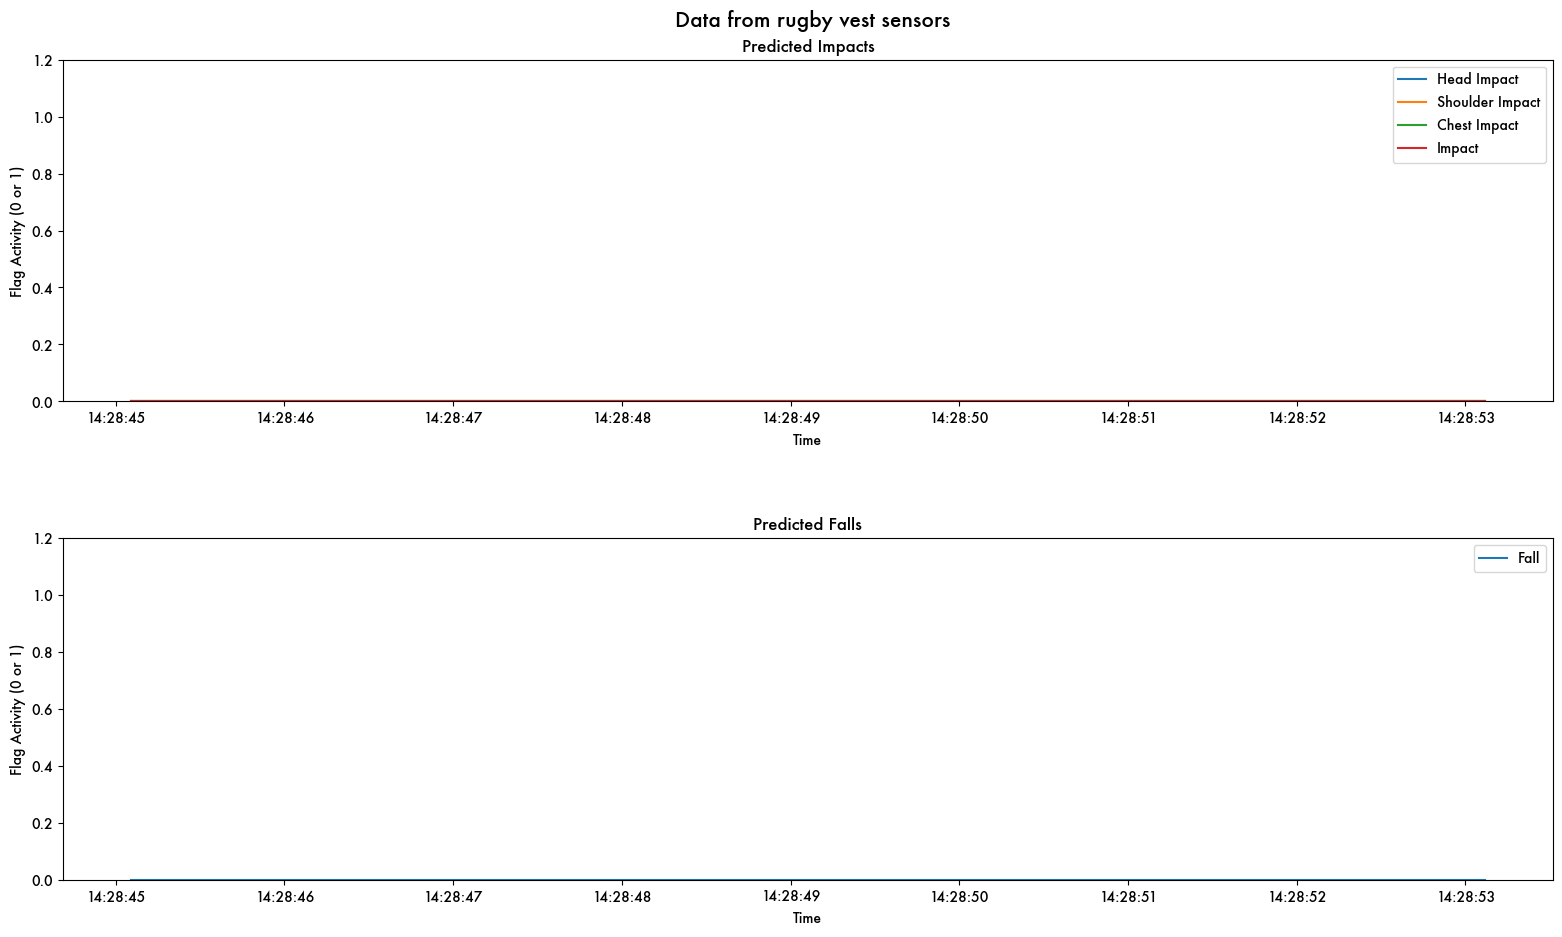

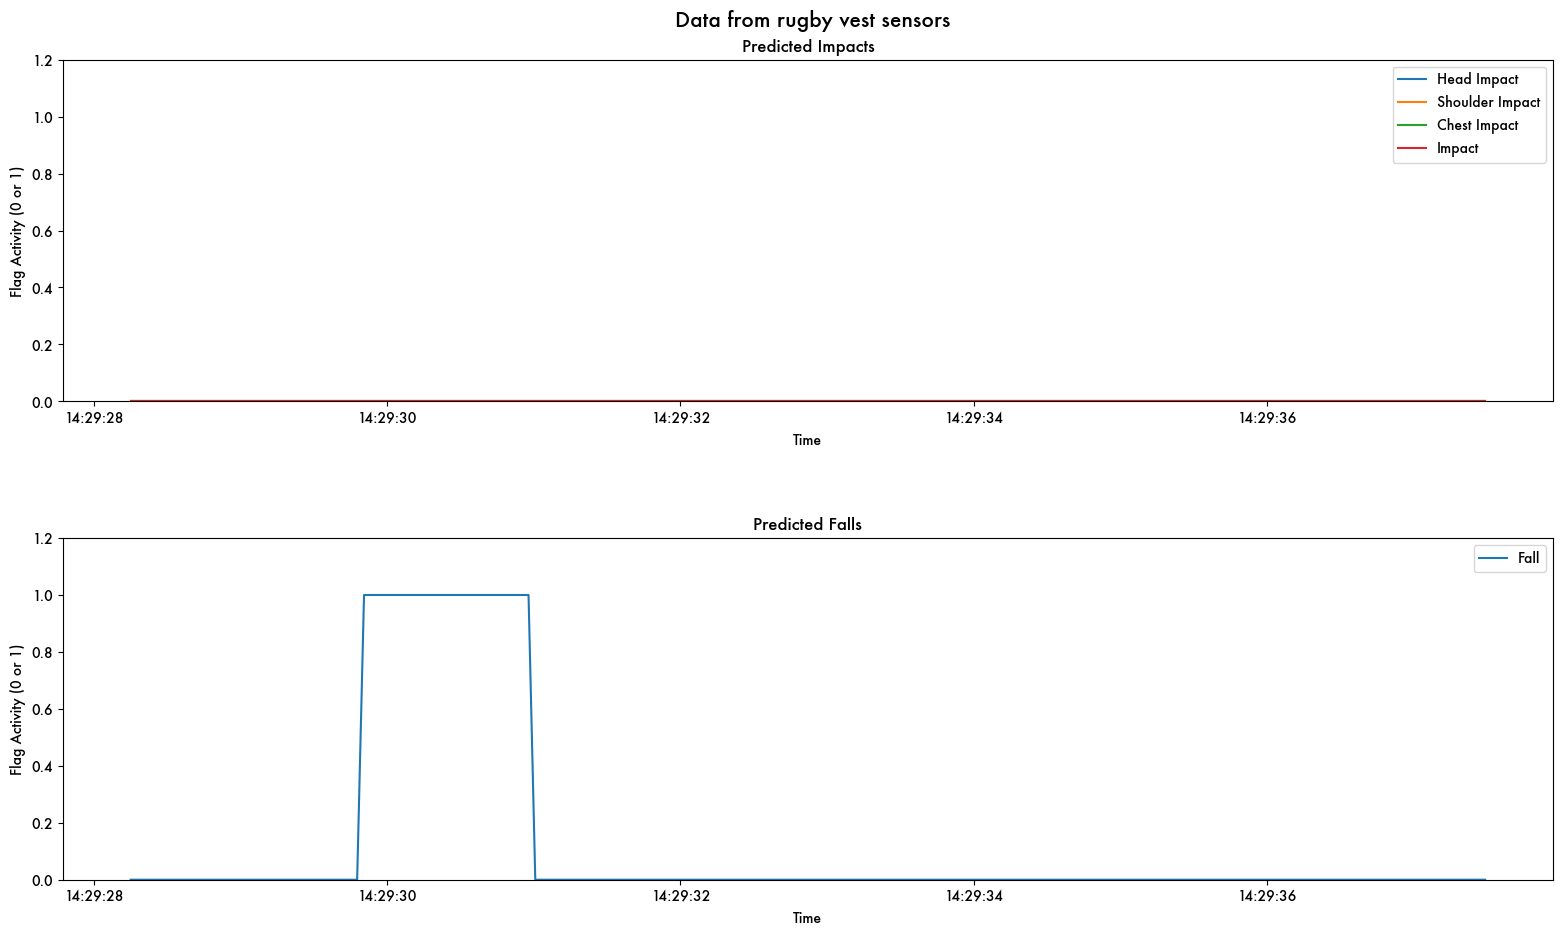

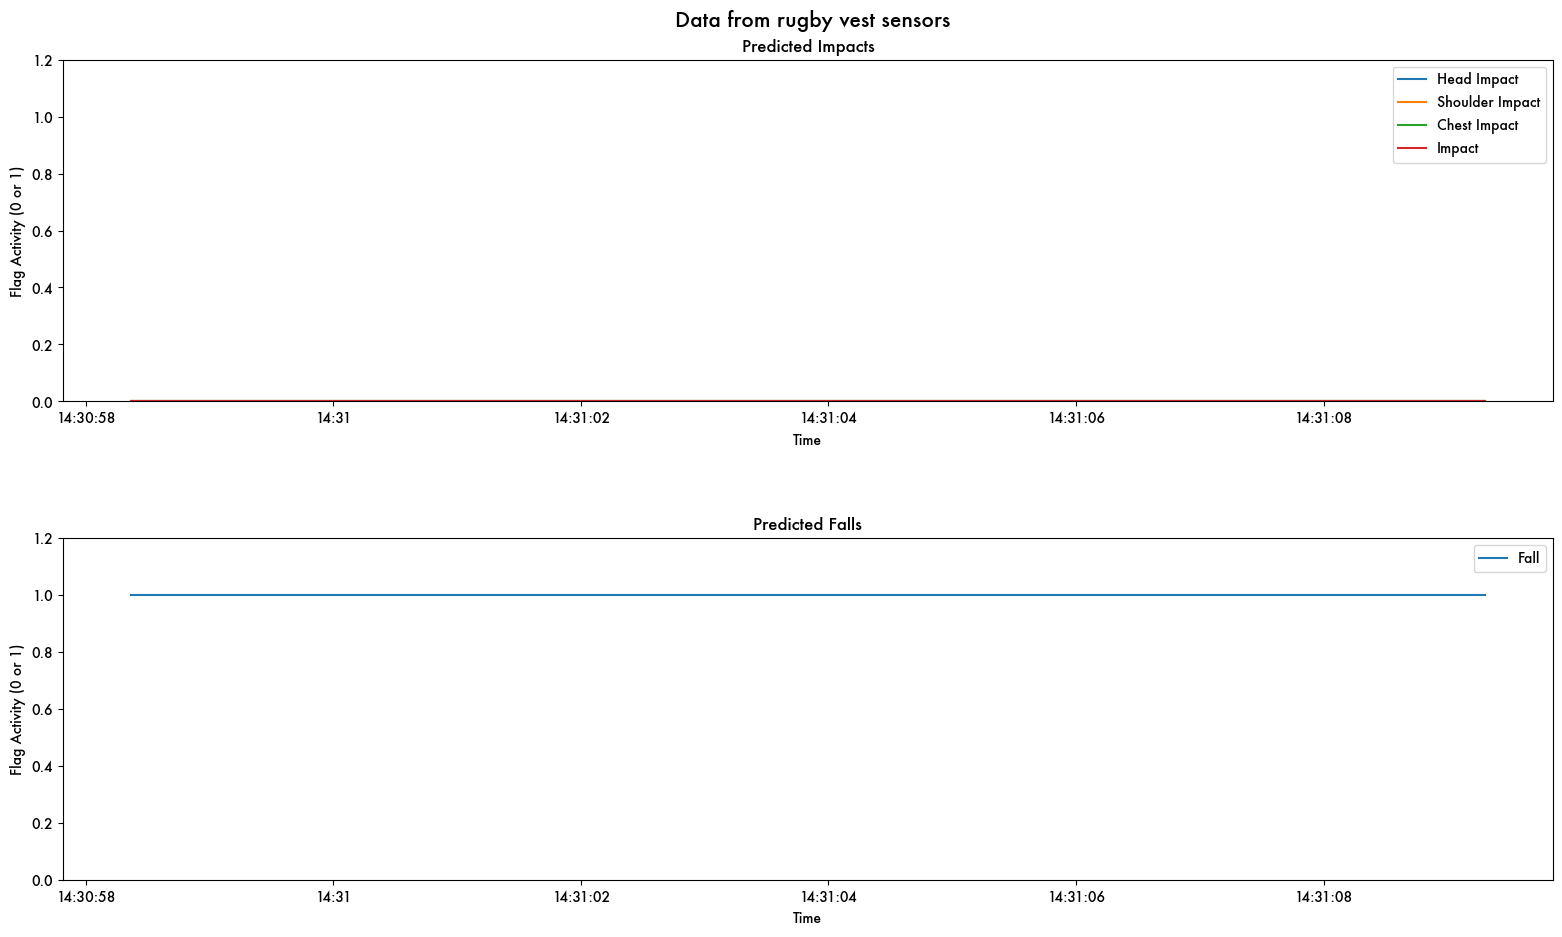

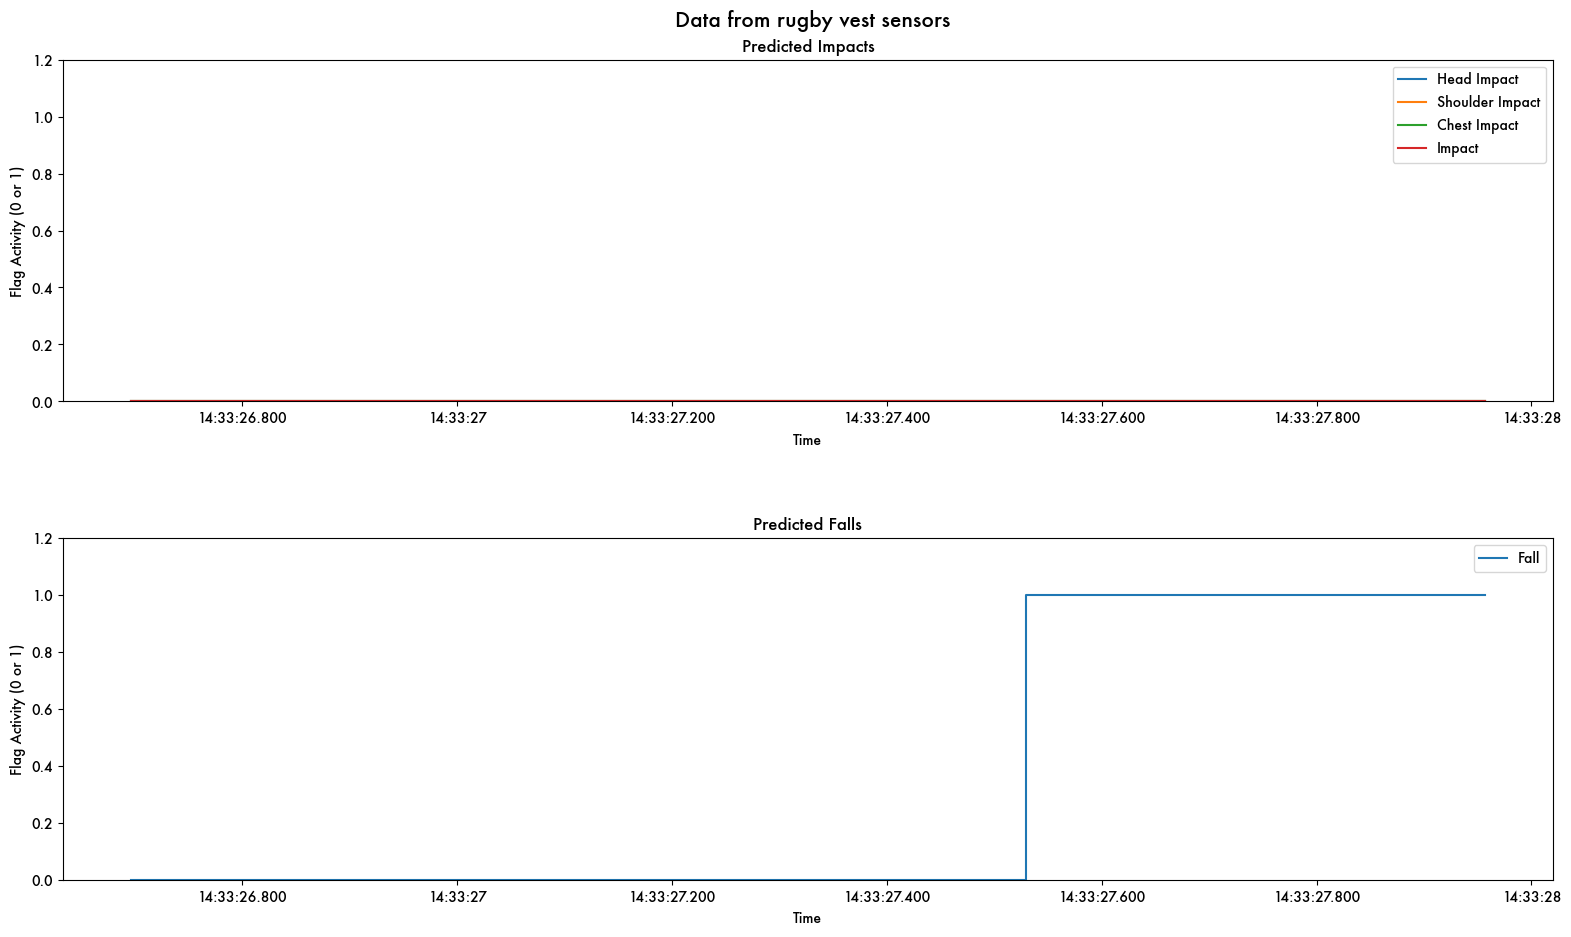

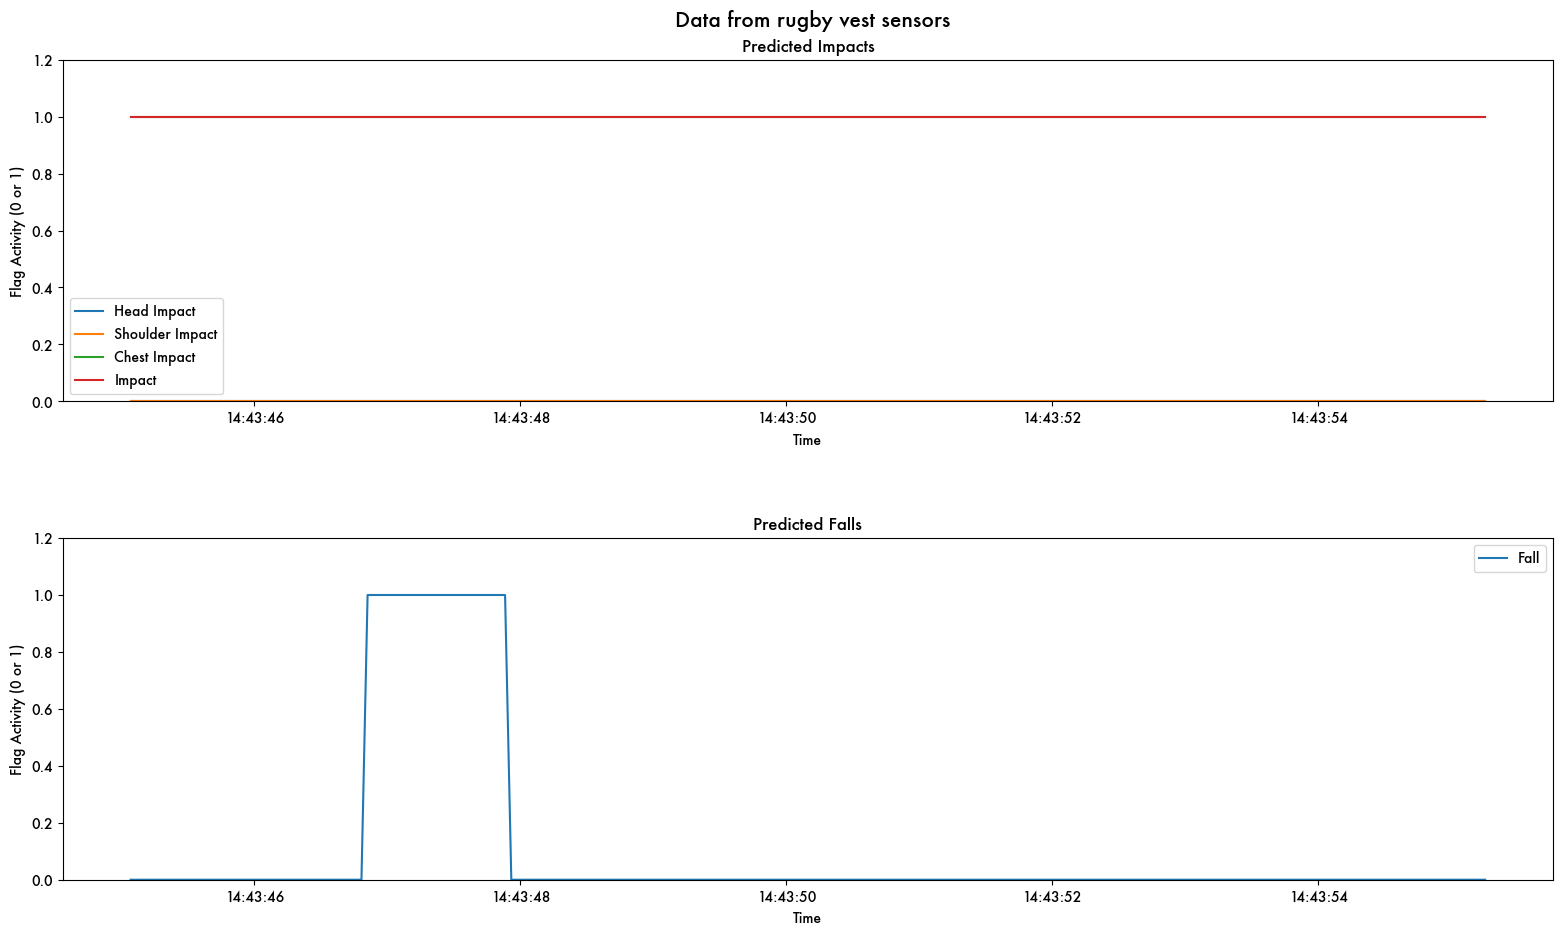

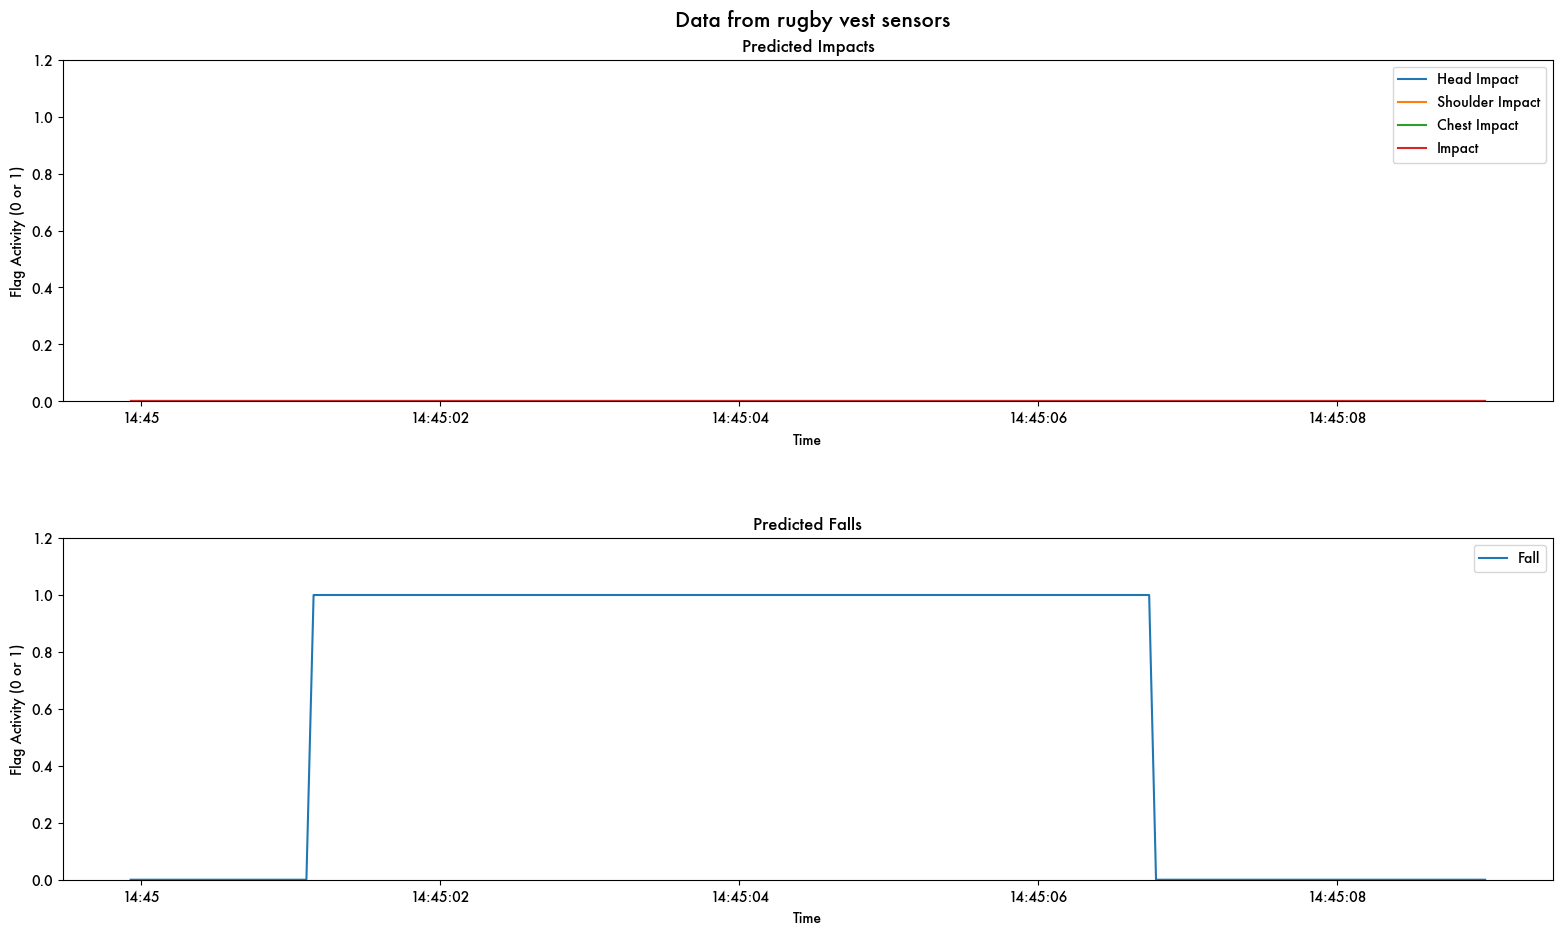

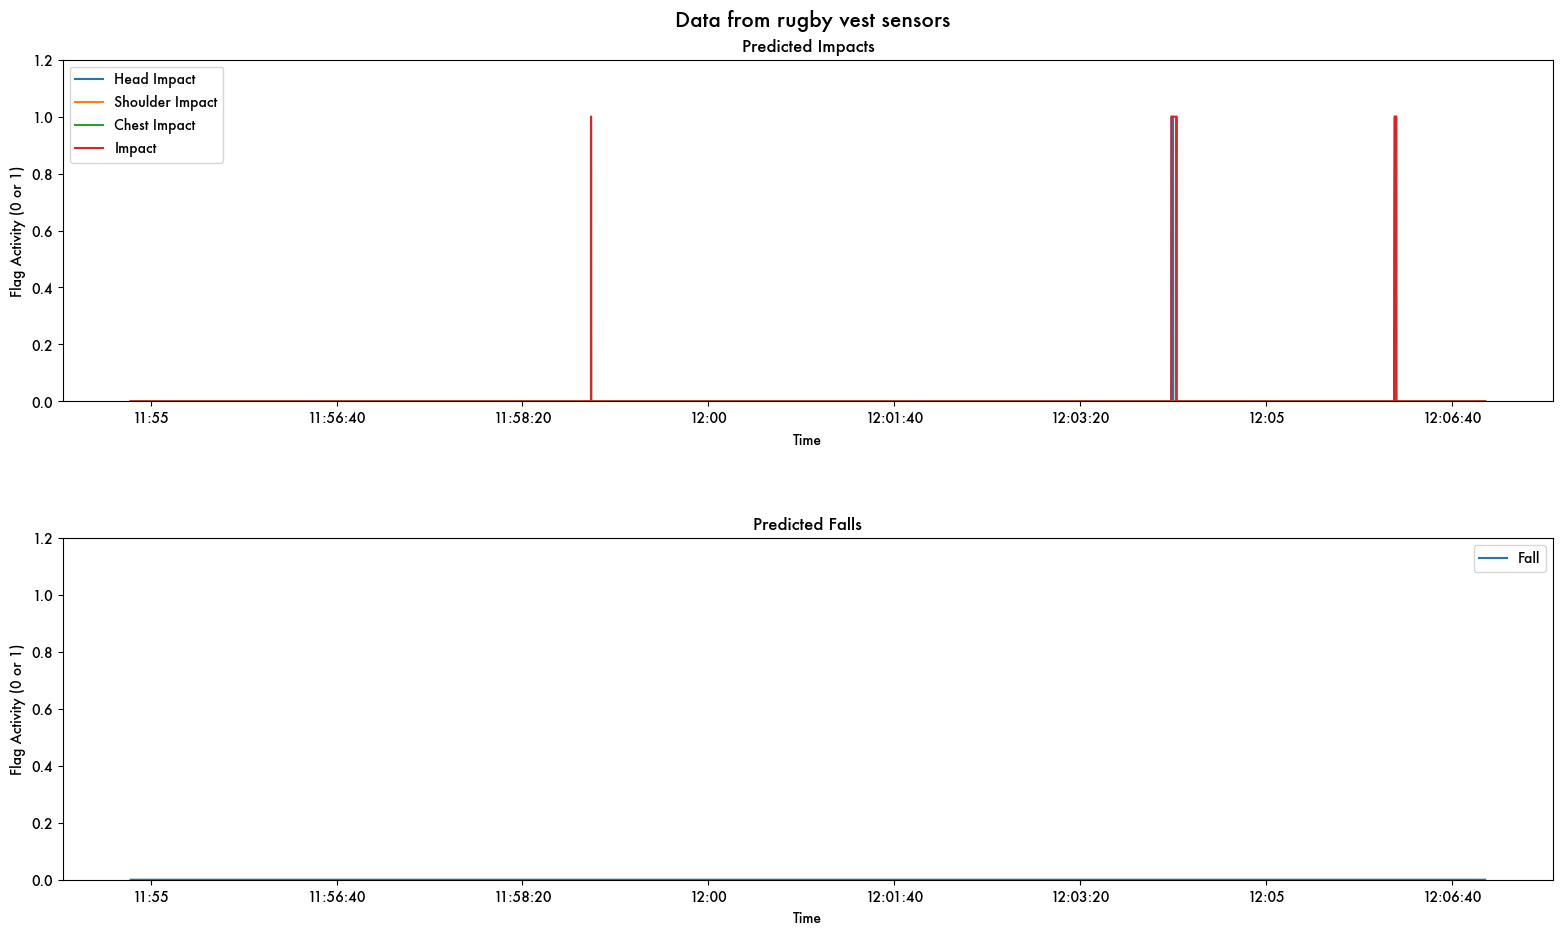

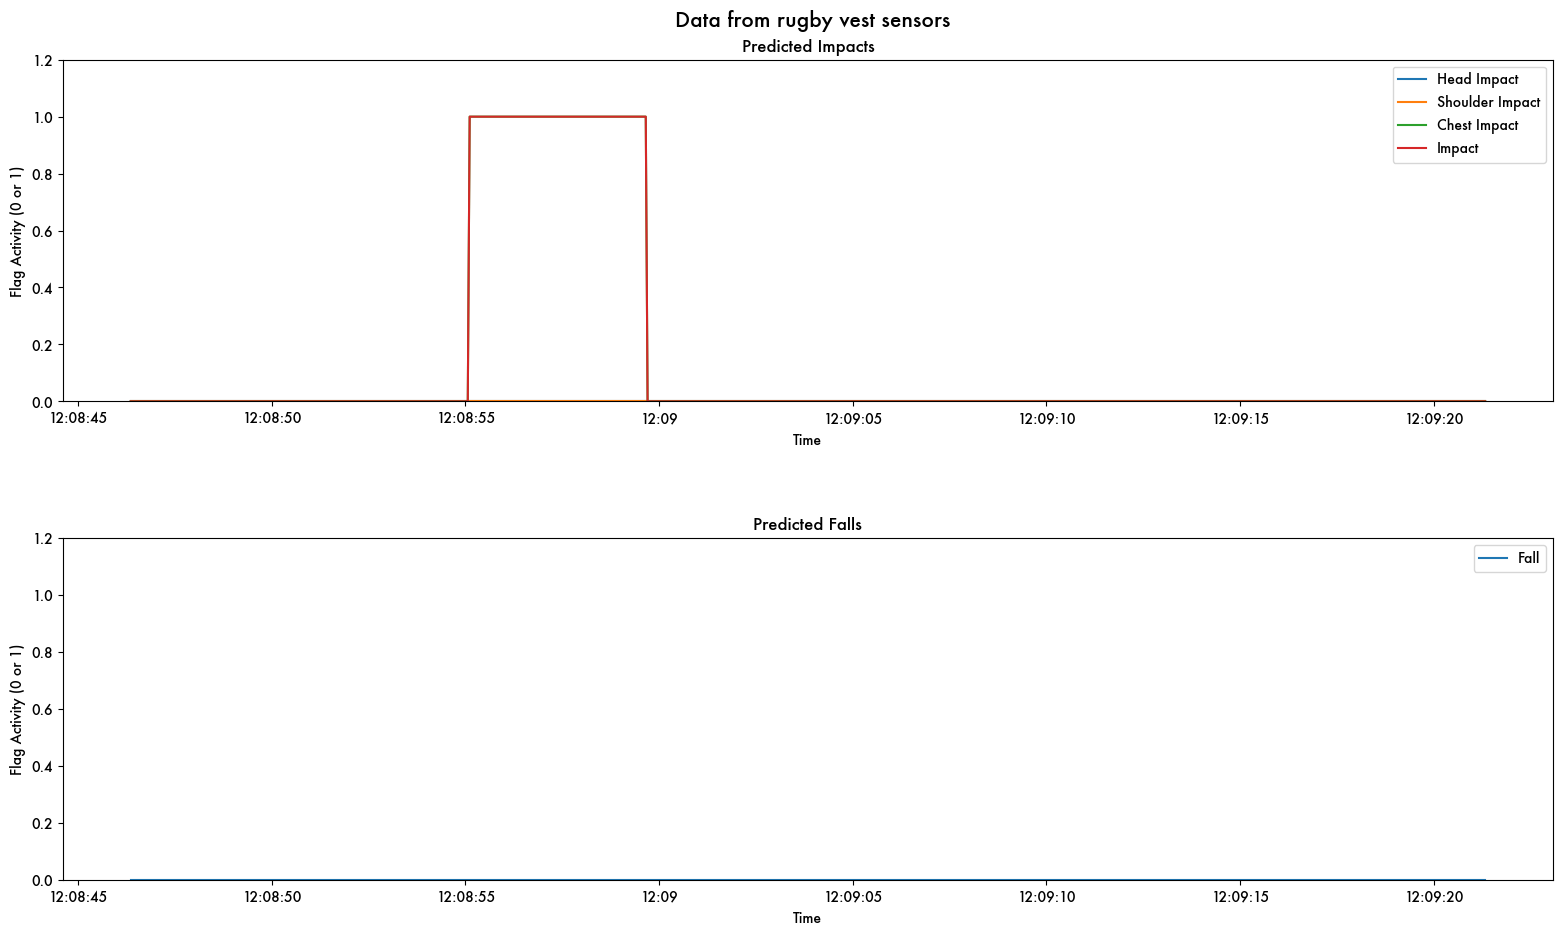

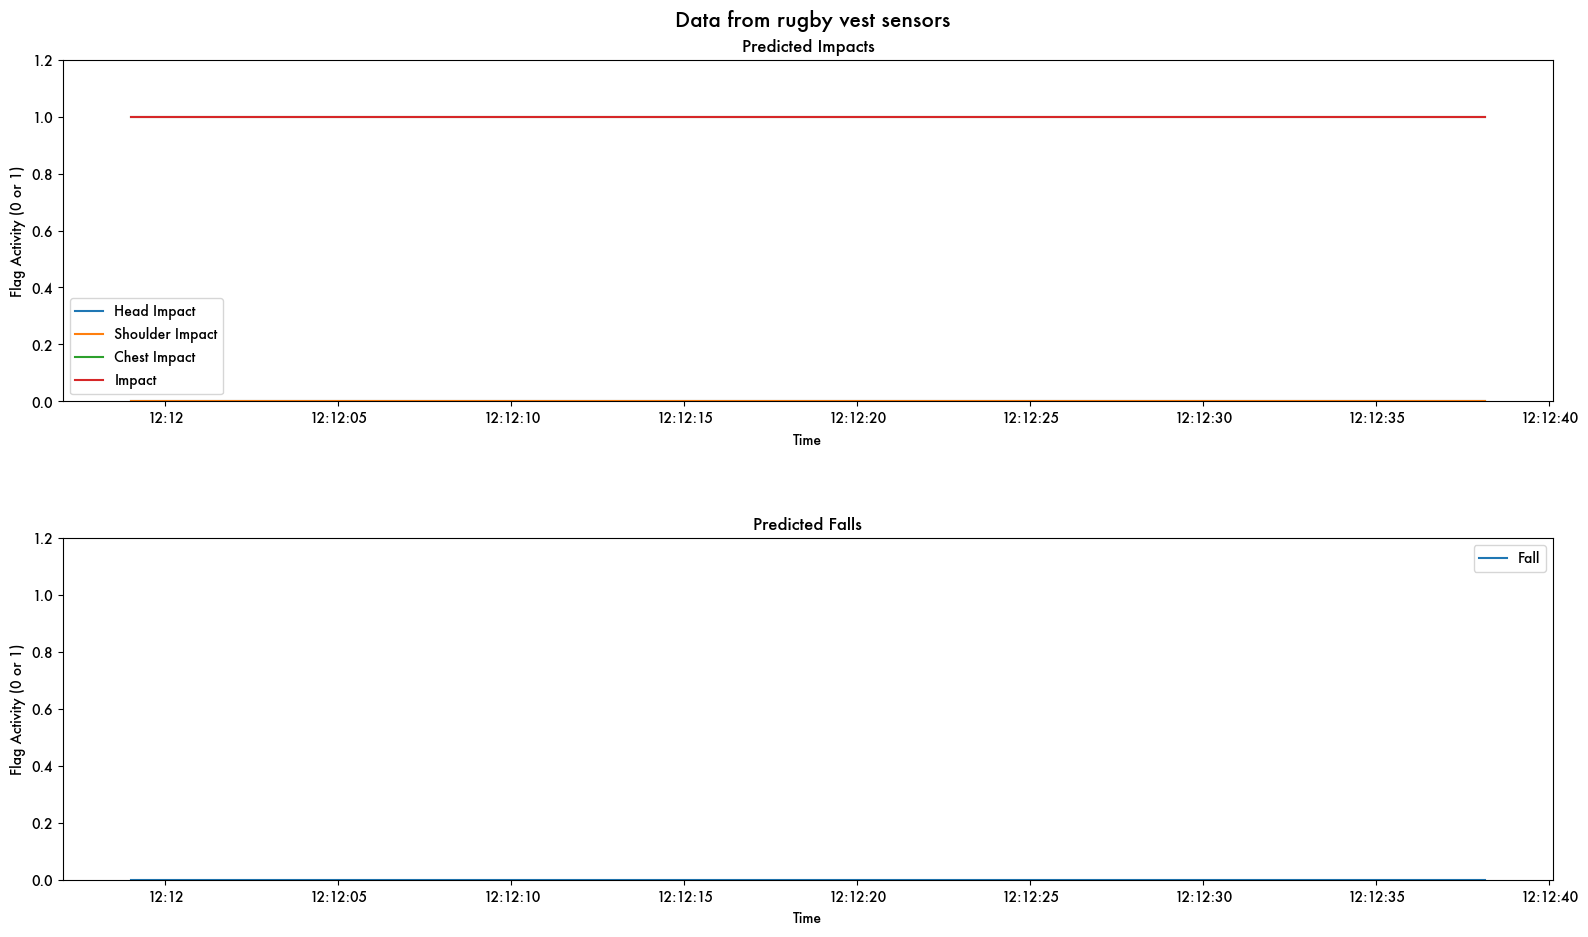

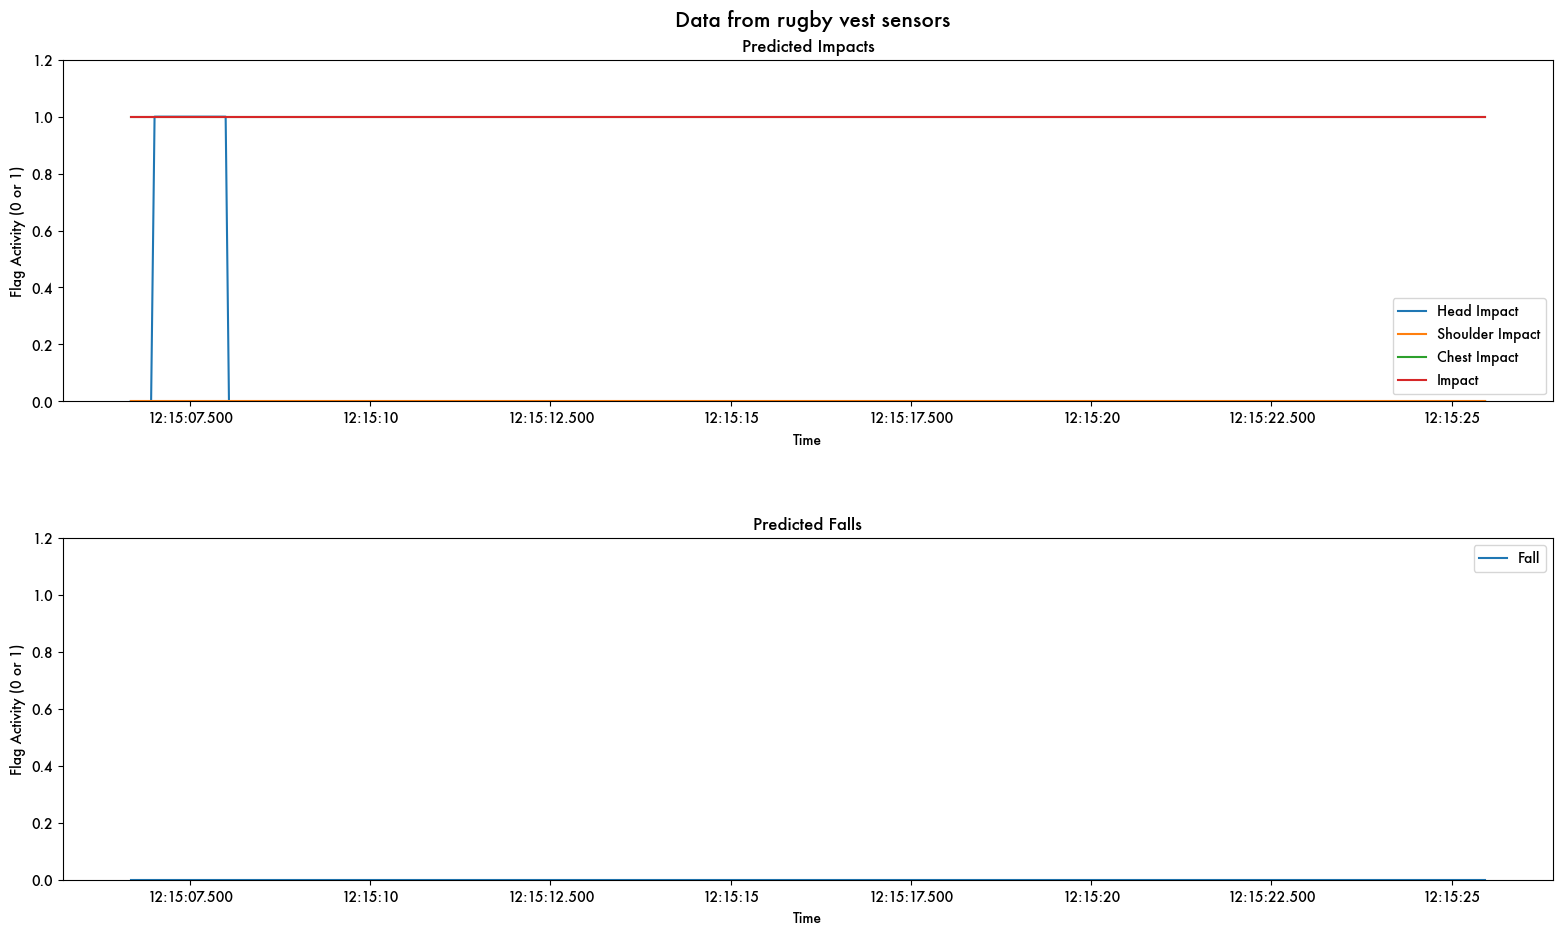

In [7]:
for i, data_table in enumerate(data_table_list_rugbyvest):

    # Define font family for the visulation
    plt.rcParams["font.family"] = "Futura"
    
    # Plot multiple graphs based on each type of sensors and time
    fig, axis = plt.subplots(figsize = (20, 10), nrows = 2, ncols = 1)
    plt.subplots_adjust(hspace = 0.4)
    fig.suptitle('Data from rugby vest sensors', fontsize = 15, fontweight = 800)
    fig.subplots_adjust(top = 0.93, right = 0.87)
    data_table.plot(x = 'Time', y = 'Head Impact', ax = axis[0], kind = 'line', title = 'Predicted Impacts', ylim = (0, 1.2), xlabel = 'Time', ylabel = 'Flag Activity (0 or 1)')
    data_table.plot(x = 'Time', y = 'Shoulder Impact', ax = axis[0], kind = 'line', title = 'Predicted Impacts', ylim = (0, 1.2), xlabel = 'Time', ylabel = 'Flag Activity (0 or 1)')
    data_table.plot(x = 'Time', y = 'Chest Impact', ax = axis[0], kind = 'line', title = 'Predicted Impacts', ylim = (0, 1.2), xlabel = 'Time', ylabel = 'Flag Activity (0 or 1)')
    data_table.plot(x = 'Time', y = 'Impact', ax = axis[0], kind = 'line', title = 'Predicted Impacts', ylim = (0, 1.2), xlabel = 'Time', ylabel = 'Flag Activity (0 or 1)')
    data_table.plot(x = 'Time', y = 'Fall', ax = axis[1], kind = 'line', title = 'Predicted Falls', ylim = (0, 1.2), xlabel = 'Time', ylabel = 'Flag Activity (0 or 1)')
    plt.show()
    

#### STEP 10: Create Visualisations for Users

This is the final step of the research, in which visualisations for end users are provided. The purpose of this visualisation is to allow team sport coaches to monitor and decide whether to replace players who have had a high number of collisions with substitute players in order to avoid injuries. With this purpose in mind, a visualisation will be created that includes counting the number of impacts and falls, ranking the highest impact among team members, and visualising impact information to follow the design on sensor spots accordingly as per below.

Before creating the visualisation, the prediction from rugby vest data and data from mouthguard will be groupped and summarised to keep only the needed information.

In [8]:
def classify_activity_type(x):
    if (x['Impact'] >= 1.0 and np.isnan(x['Fall'])):
        return 'Impact'
    elif (np.isnan(x['Impact']) and x['Fall'] == 1):
        return 'Fall'
    elif (x['Impact'] >= 1 and x['Fall'] == 1):
        return 'Impact and Fall'
    else:
        return np.nan
    
def classify_activity_start_time(x):
    if (x['Impact'] >= 1.0 and np.isnan(x['Fall'])):
        return x['Impact_start']
    elif (np.isnan(x['Impact']) and x['Fall'] == 1):
        return x['Fall_start']
    elif (x['Impact'] >= 1 and x['Fall'] == 1):
        return x['Impact_start']
    else:
        return np.nan
    
def classify_activity_duration(x):
    if (x['Impact'] >= 1.0 and np.isnan(x['Fall'])):
        return x['Impact_duration']
    elif (np.isnan(x['Impact']) and x['Fall'] == 1):
        return x['Fall_duration']
    elif (x['Impact'] >= 1 and x['Fall'] == 1):
        if x['Impact_duration'] > x['Fall']:
            return x['Impact_start']
        else:
            return x['Fall']
    else:
        return np.nan

In [9]:
# Prepare result for creating visualisation

# Group data from impacts
impact_grouped_data = pd.DataFrame([])
impact_segmented_list = []
for data_table in data_table_list_rugbyvest:
    data_table = data_table[data_table['Impact'] == 1]
    impact_grouped_data_temp = data_table.groupby(['Group_Impact', 'Impact_start', 'Impact_duration'], as_index=False).sum()
    # Prepare segment information of impact for generating Gif
    for i in range(len(impact_grouped_data_temp)):
        selected_cols = ['Time', *shoulder1_colnames, *shoulder2_colnames, *chest1_colnames, *chest2_colnames, 'Head Impact', 'Head Impact Location']
        impact_segment = data_table[data_table['Group_Impact'] == impact_grouped_data_temp.iloc[i]['Group_Impact']]
        impact_segmented_list.append(impact_segment[selected_cols])
    impact_grouped_data_temp = impact_grouped_data_temp.drop(impact_grouped_data_temp.columns.difference(['Impact', 'Impact_start', 'Impact_duration', 'Head Impact', 'Shoulder Impact', 'Chest Impact']), axis=1)
    impact_grouped_data = impact_grouped_data.append(impact_grouped_data_temp, ignore_index=True)
    # Calculate total impact time for dashboard
    total_time_under_impacts = round(impact_grouped_data['Impact_duration'].sum(),3)
    
# Group data from falls
fall_grouped_data = pd.DataFrame([])
for data_table in data_table_list_rugbyvest:
    data_table = data_table[data_table['Fall'] == 1]
    fall_grouped_data_temp = data_table.groupby(['Group_Impact', 'Fall', 'Fall_start', 'Fall_duration'], as_index=False).sum()
    fall_grouped_data_temp = fall_grouped_data_temp.drop(fall_grouped_data_temp.columns.difference(['Fall', 'Fall_start', 'Fall_duration', 'Head Impact', 'Shoulder Impact', 'Chest Impact']), axis=1)
    fall_grouped_data = fall_grouped_data.append(fall_grouped_data_temp, ignore_index=True)
    
# Re-label the flags for showing on the dashboard
impact_fall_merged = impact_grouped_data.append(fall_grouped_data, ignore_index = True)
impact_fall_merged['Activity_type'] = impact_fall_merged.apply(classify_activity_type, axis=1)
impact_fall_merged['Activity_start'] = impact_fall_merged.apply(classify_activity_start_time, axis=1).astype(str).apply(lambda x: x.split('.')[0])
impact_fall_merged['Activity_duration'] = impact_fall_merged.apply(classify_activity_duration, axis=1).round(decimals=3)
impact_fall_merged['Activity_duration_plot'] = impact_fall_merged.apply(lambda x: 1 if x['Activity_duration'] < 1 else x['Activity_duration'], axis=1) # To make it visible in graph for the data in this research only
impact_fall_merged['Impacted_head'] = impact_fall_merged.apply(lambda x: 'Yes' if x['Head Impact'] > 0 else 'No', axis=1)
impact_fall_merged['Impacted_shoulder'] = impact_fall_merged.apply(lambda x: 'Yes' if x['Shoulder Impact'] > 0 else 'No', axis=1)
impact_fall_merged['Impacted_chest'] = impact_fall_merged.apply(lambda x: 'Yes' if x['Chest Impact'] > 0 else 'No', axis=1)
impact_fall_merged = impact_fall_merged.drop(['Impact', 'Fall', 'Impact_start', 'Fall_start', 'Impact_duration', 'Fall_duration', 'Head Impact', 'Shoulder Impact', 'Chest Impact'], axis=1)
impact_fall_merged = impact_fall_merged[impact_fall_merged['Activity_duration'] > 0]
impact_fall_merged = impact_fall_merged[impact_fall_merged['Activity_type'] == 'Impact']
impact_fall_merged = impact_fall_merged.reset_index(drop=True)
display(impact_fall_merged)


,Activity_type,Activity_start,Activity_duration,Activity_duration_plot,Impacted_head,Impacted_shoulder,Impacted_chest
0,Impact,14:43:45,10.187,10.187,No,No,Yes
1,Impact,11:58:56,0.050,1.000,No,No,Yes
2,Impact,12:04:09,2.724,2.724,Yes,No,Yes
3,Impact,12:06:09,0.873,1.000,Yes,No,No
4,Impact,12:08:55,4.546,4.546,No,No,Yes
5,Impact,12:11:58,39.161,39.161,No,No,Yes
6,Impact,12:15:06,18.789,18.789,Yes,No,Yes


#### Illustrate Sensors on Rugby Vest with Impacts

In [10]:
# Define Gif info
gif_metadata = dict(title = 'Rugby Vest Sensors', artist = 'NA')
gif_writer = PillowWriter(fps = 5, metadata = gif_metadata)

# Create a figure with selected background (shirt)
shirt_bg = plt.imread(folder_path + folder_input_visualisation + "v-neck shirt.png")
fig, axis = plt.subplots()
axis.imshow(shirt_bg, interpolation = 'lanczos') # High quality result
axis.set_aspect('equal') # Equal aspect ratio
axis.axis('off') # Hide axis

# Define the colormap from gray (no impact which equals to high value) to red (high impact which equals to low value)
set_sensors_color = mcolors.LinearSegmentedColormap.from_list('custom_colormap', ['red', 'gray'])

# Generate gif files from segments labelled as impact
for i, segment in enumerate(impact_segmented_list):
            
    with gif_writer.saving(fig, folder_path + folder_output + 'impact_segment_' + str(i) + '.gif', 100):

        for row_data in segment.iterrows():
            
            col_data = 0 # Column number 0-31 = 32 columns (16 shoulder sensors, 16 chest sensors)

            # Plot the circles to represent sensors and set the colour based on value
            for i_row in range(shoulder_sensors_rows):
                for i_col in range(shoulder_sensors_cols):
                    axis.add_patch(plt.Circle((shoulder_sensors_x_pos[i_row][i_col], shoulder_sensors_y_pos[i_row][i_col]), circle_radius, color = set_sensors_color(row_data[1][col_data + 1])))
                    col_data += 1
            for i_row in range(chest_sensors_rows):
                for i_col in range(chest_sensors_cols):
                    axis.add_patch(plt.Circle((chest_sensors_x_pos[i_row][i_col], chest_sensors_y_pos[i_row][i_col]), circle_radius, color = set_sensors_color(row_data[1][col_data + 1])))
                    col_data += 1
            
            # Add time label in each frame
            time_label = plt.text(1, 1, row_data[1][0], fontsize=14)

            # Display frame
#             plt.show()

            # Get frame of current plot for gif
            gif_writer.grab_frame()

            # Clear all patches (circles) from the axis to get ready for the next frame
            for patch in axis.patches:
                patch.remove()
            
            # Clear time label
            time_label.remove()

        print('Completely generated for segment', i)
            
# Clear the plot
plt.close()
print('All impact is generated')


Completely generated for segment 0
Completely generated for segment 1
Completely generated for segment 2
Completely generated for segment 3
Completely generated for segment 4
Completely generated for segment 5
Completely generated for segment 6
All impact is generated


#### Illustrate Mouthguard Detecting Position on Human Head with Impacts

In [11]:


# Define Gif info
gif_metadata = dict(title = 'Mouthguard Sensors', artist = 'NA')
gif_writer = PillowWriter(fps = 5, metadata = gif_metadata)

# Create a figure with selected background (shirt)
face_bg = plt.imread(folder_path + folder_input_visualisation + "head.png")
fig, axis = plt.subplots()
axis.imshow(face_bg, interpolation = 'lanczos') # High quality result
axis.set_aspect('equal') # Equal aspect ratio
axis.axis('off') # Hide axis

# Generate gif files from segments labelled as impact
for i, segment in enumerate(impact_segmented_list):
            
    with gif_writer.saving(fig, folder_path + folder_output + 'head_impact_segment_' + str(i) + '.gif', 100):

        for row_data in segment.iterrows():

            col_data = 33 # Column number 33 only

            # Plot the circles to represent sensors and set the colour based on value
            for i_sensor in range(4):
                if i_sensor == 1 and row_data[1][col_data + 1] == 'RIGHT_HIGH':
                    sensor_color = 'red'
                elif i_sensor == 2 and row_data[1][col_data + 1] == 'RIGHT_LOW':
                    sensor_color = 'red'
                elif i_sensor == 3 and row_data[1][col_data + 1] == 'LEFT_HIGH':
                    sensor_color = 'red'
                elif i_sensor == 4 and row_data[1][col_data + 1] == 'LEFT_LOW':
                    sensor_color = 'red'
                else:
                    sensor_color = 'gray'
                axis.add_patch(plt.Circle((head_sensors_x_pos[i_sensor], head_sensors_y_pos[i_sensor]), circle_radius, color = sensor_color))

            # Add time label in each frame
            time_label = plt.text(1, 5, row_data[1][0], fontsize = 14, color = 'white')

            # Display frame
#             plt.show()

            # Get frame of current plot for gif
            gif_writer.grab_frame()

            # Clear all patches (circles) from the axis to get ready for the next frame
            for patch in axis.patches:
                patch.remove()
            
            # Clear time label
            time_label.remove()

        print('Completely generated for segment', i)
            
# Clear the plot
plt.close()
print('All impact is generated')



Completely generated for segment 0
Completely generated for segment 1
Completely generated for segment 2
Completely generated for segment 3
Completely generated for segment 4
Completely generated for segment 5
Completely generated for segment 6
All impact is generated


#### Create Dashboard for End-Users

In [15]:
# Generate horizontal bar graph
data_source_hbar = ColumnDataSource(impact_fall_merged)
duration_hbar = figure(y_range = FactorRange(*impact_fall_merged['Activity_start']), width = 300, height = 230, tools="pan,wheel_zoom,reset", toolbar_location = 'right')
duration_hbar.hbar(y = 'Activity_start', right = 'Activity_duration_plot', source = data_source_hbar, height = 0.6, fill_color = '#898467', line_color = None, selection_color = "#898467", nonselection_fill_color = "#EBEAE8", nonselection_fill_alpha = 1, nonselection_line_alpha = 0)
duration_hbar.xaxis.axis_label = "Duration of Activity (Seconds)"
duration_hbar.yaxis.axis_label = "Time Activity Occurred"
duration_hbar.xgrid.grid_line_color = None
duration_hbar.ygrid.grid_line_dash = [4, 5]
duration_hbar.xaxis.axis_label_text_font = 'Futura'
duration_hbar.yaxis.axis_label_text_font = 'Futura'
duration_hbar.xaxis.major_label_text_font = 'Futura'
duration_hbar.yaxis.major_label_text_font = 'Futura'
duration_hbar.xaxis.axis_label_text_font_style = 'normal'
duration_hbar.yaxis.axis_label_text_font_style = 'normal'

# Read external file for custom javascript code
bokeh_customjs = folder_path + folder_input_visualisation + "bokeh_customjs.js"
with open(bokeh_customjs, 'r') as file_bokeh_customjs:
    bokeh_customjs_code = file_bokeh_customjs.read()
shutil.copy2(folder_path + folder_input_visualisation + "customjs.js", folder_path + folder_output) # target filename is /dst/dir/file.ext
shutil.copy2(folder_path + folder_input_visualisation + "styles.css", folder_path + folder_output) # target filename is /dst/dir/file.ext
shutil.copy2(folder_path + folder_input_visualisation + "rugby-player.png", folder_path + folder_output) # target filename is /dst/dir/file.ext
shutil.copy2(folder_path + folder_input_visualisation + "rugby-player2.png", folder_path + folder_output) # target filename is /dst/dir/file.ext
shutil.copy2(folder_path + folder_input_visualisation + "rugby-player3.png", folder_path + folder_output) # target filename is /dst/dir/file.ext
shutil.copy2(folder_path + folder_input_visualisation + "rugby-player4.png", folder_path + folder_output) # target filename is /dst/dir/file.ext
shutil.copy2(folder_path + folder_input_visualisation + "rugby-player5.png", folder_path + folder_output) # target filename is /dst/dir/file.ext

# Apply custom javascript code with graphs
hbar_tap_callback = CustomJS(args=dict(source=data_source_hbar), code=f"""{bokeh_customjs_code}\nhbar_onclick(source.selected.indices);""")
duration_hbar.add_tools(TapTool(callback = hbar_tap_callback))

# Generate the javascripts and html div components (Bokeh plot components) for graphs
duration_hbar_script, duration_hbar_div = components(duration_hbar)

# Load the HTML template file from folder
env = Environment(loader = FileSystemLoader(folder_path + folder_input_visualisation))
template = env.get_template("dashboard_template.html")

# Render the template with the Bokeh plot components and other variables
html_output = template.render(
    styles_css = styles_css,
    custom_js = custom_js,
    # Mock up data
    player_firstname = player_firstname,
    player_lastname = player_lastname,
    player_icon = player_icon,
    player_height = player_height,
    player_weight = player_weight,
    # Data from prediction and mouthguard
    impact_detected = total_impacts,
    head_impact_detected = total_head_impacts,
    shoulder_impact_detected = total_shoulder_impacts,
    chest_impact_detected = total_chest_impacts,    
    fall_detected = total_falls,
    impact_duration_detected = total_time_under_impacts,
    duration_hbar_script = duration_hbar_script,
    duration_hbar_div = duration_hbar_div,
    head_gif = head_gif,
    impact_gif = impact_gif
)

# Export the rendered html (dashboard) to a html file
output_file_path = folder_path + folder_output + "output.html"
output_file(output_file_path)
with open(output_file_path, "w") as f:
    f.write(html_output)
    print('Exported dashboard to', output_file_path)

Exported dashboard to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/output.html


#### The end of the code for this disseration. For part 1, refer to code_1_preparation.ipynb.